# Scikit-learn PCA 實作

PCA 做的事像這樣：

先找一條「最重要的線」
這條線的方向是：
資料沿著它分散得最開（變異最大）
也就是「最能看出差異」的方向。
這條線叫 第一主成分（PC1）。

把每個點「打到這條線上」（投影）
你原本每個點有很多特徵（很多維），
投影後，你只要記得它在線上的位置（1 個數字）就好。
→ 多維變 1 維

如果你要保留更多資訊
再找第二條方向（PC2）：

它也要讓變異大

但不能跟第一條重複（要垂直/獨立）
然後投影到 PC1 + PC2 平面上
→ 多維變 2 維

In [1]:
from sklearn import datasets
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
ds = datasets.load_wine()
df = pd.DataFrame(ds.data,columns=ds.feature_names)
df.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0


In [3]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
X = df.values
y = ds.target
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.3)
X_train.shape,X_test.shape,y_train.shape,y_test.shape

((124, 13), (54, 13), (124,), (54,))

In [4]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_std =  scaler.fit_transform(X_train)
X_test_std = scaler.transform(X_test)


## 特徵萃取(PCA)

In [5]:
from sklearn.decomposition import PCA
pcal = PCA(n_components=2)
X_train_pca = pcal.fit_transform(X_train_std)
X_test_pca = pcal.transform(X_test_std)
X_train_pca.shape,X_test_pca.shape

((124, 2), (54, 2))

In [6]:
from sklearn.linear_model import LogisticRegression
clf = LogisticRegression()
clf.fit(X_train_std,y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

## 無PCA

In [7]:
y_pred = clf.predict(X_test_std)
print(f"Accuracy:{accuracy_score(y_test,y_pred)}")

Accuracy:0.9814814814814815


In [8]:
from sklearn.linear_model import LogisticRegression
clf = LogisticRegression()
clf.fit(X_train_pca,y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [9]:
y_pred_pca = clf.predict(X_test_pca)
print(f"PCA Accuracy:{accuracy_score(y_test,y_pred_pca):.2f}")

PCA Accuracy:0.96


## 特徵萃取(KernelPCA)

In [10]:
from sklearn.decomposition import KernelPCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_std =  scaler.fit_transform(X_train)
X_test_std = scaler.transform(X_test)

kpca = KernelPCA(n_components=2,kernel='rbf',gamma=10)
X_train_kpca = kpca.fit_transform(X_train_std)
X_test_kpca = kpca.transform(X_test_std)
print(X_train_kpca.shape,X_test_kpca.shape)

clf = LogisticRegression()
clf.fit(X_train_kpca,y_train)
y_pred = clf.predict(X_test_kpca)
print(f"KPCA Accuracy:{accuracy_score(y_test,y_pred):.2f}")


(124, 2) (54, 2)
KPCA Accuracy:0.46


In [14]:
from sklearn.decomposition import KernelPCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
best = (-1,None)
g = 0.05 
for g in [0.01,0.05,0.1,0.2,0.5,1,2,5,10,20,50]:
    kpca = KernelPCA(n_components=2,kernel='rbf',gamma=g)
    X_train_kpca = kpca.fit_transform(X_train_std)
    X_test_kpca = kpca.transform(X_test_std)
    clf = LogisticRegression()
    clf.fit(X_train_kpca,y_train)
    y_pred = clf.predict(X_test_kpca)
    acc = accuracy_score(y_test,y_pred)
    print(f"gamma={g},Accuracy:{acc:.2f}")
    if acc > best[0]:
        best = (acc,g)
print(f"baset:{best}")        

gamma=0.01,Accuracy:0.96
gamma=0.05,Accuracy:0.98
gamma=0.1,Accuracy:0.98
gamma=0.2,Accuracy:0.96
gamma=0.5,Accuracy:0.72
gamma=1,Accuracy:0.48
gamma=2,Accuracy:0.46
gamma=5,Accuracy:0.46
gamma=10,Accuracy:0.46
gamma=20,Accuracy:0.46
gamma=50,Accuracy:0.46
baset:(0.9814814814814815, 0.05)


# 簡單線性回歸導論

簡單線性回歸的核心公式是找到最佳擬合直線，即所謂的回歸線，其公式可以表示為：

$ y = \beta_0 + \beta_1 x $

其中：
- $ y $ 是應變量（依賴變量）。
- $ x $ 是自變量（獨立變量）。
- $ \beta_0 $ 是截距，即直線在 $ y $ 軸的交點。
- $ \beta_1 $ 是斜率，表示 $ x $ 變動一單位時 $ y $ 的變動量。

### 參數估計
使用最小二乘法來估計 $ \beta_0 $ 和 $ \beta_1 $，計算公式如下：

$ \beta_1 = \frac{\sum_{i=1}^n (x_i - \bar{x})(y_i - \bar{y})}{\sum_{i=1}^n (x_i - \bar{x})^2} $

$ \beta_0 = \bar{y} - \beta_1 \bar{x} $

其中：
- $ \bar{x} $ 和 $ \bar{y} $ 分別是 $ x $ 和 $ y $ 的平均值。
- $ n $ 是數據點的數量。

### 計算範例
假設我們有以下的數據點：

| $ x $ (年經驗) | $ y $ (年薪，單位：萬元) |
|---------|------------------|
| 1       | 3                |
| 2       | 4                |
| 3       | 5                |
| 4       | 6                |

我們要找到這些數據的線性回歸方程。首先計算 $ x $ 和 $ y $ 的平均值：

$[\bar{x} = \frac{1 + 2 + 3 + 4}{4} = 2.5]$

$ \bar{y} = \frac{3 + 4 + 5 + 6}{4} = 4.5 $

接下來計算斜率 $ \beta_1 $：

$ \beta_1 = \frac{(1-2.5)(3-4.5) + (2-2.5)(4-4.5) + (3-2.5)(5-4.5) + (4-2.5)(6-4.5)}{(1-2.5)^2 + (2-2.5)^2 + (3-2.5)^2 + (4-2.5)^2} = \frac{(-1.5)(-1.5) + (-0.5)(-0.5) + (0.5)(0.5) + (1.5)(1.5)}{2.5} = 1 $

計算截距 $ \beta_0 $：

$ \beta_0 = 4.5 - 1 \times 2.5 = 2 $

因此，回歸方程為：

$ y = 2 + 1x $

或簡化為：

$ y = 2 + x $

這樣，給定任何 $ x $ 的值，我們都可以使用這個方程來預測 $ y $ 的值。例如，若一人具有 5 年的經驗，其年薪預估為：

$ y = 2 + 5 = 7 $（單位：萬元）



In [15]:
df = pd.read_csv("./Advertising.csv")
df.head()

,TV,radio,newspaper,sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9


In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [17]:
df["total_spend"] = df["TV"] + df["radio"] +df["newspaper"]

<Axes: xlabel='total_spend', ylabel='sales'>

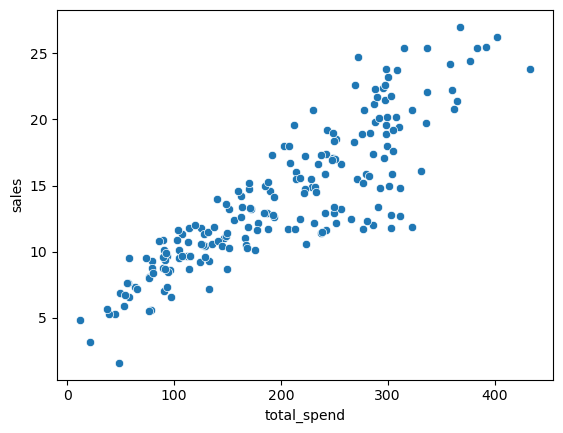

In [18]:
sns.scatterplot(x="total_spend",y="sales",data=df)

In [20]:
x = df["total_spend"]
y = df["sales"]

x_mean = np.mean(x)
y_mean = np.mean(y)

beta_1 = np.sum((x - x_mean) * (y - y_mean)) / np.sum((x - x_mean) ** 2)
beta_0 = y_mean - beta_1 * x_mean
print(f"y={beta_0:.2f}+{beta_1:.2f}x")

y=4.24+0.05x


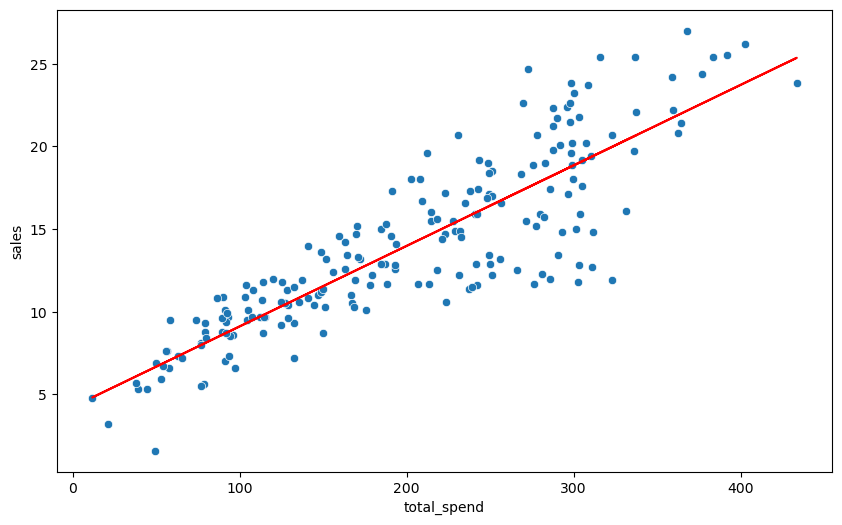

In [21]:
plt.figure(figsize=(10,6))
sns.scatterplot(x="total_spend",y="sales",data=df)
plt.plot(x,beta_0+beta_1*x,c="red")

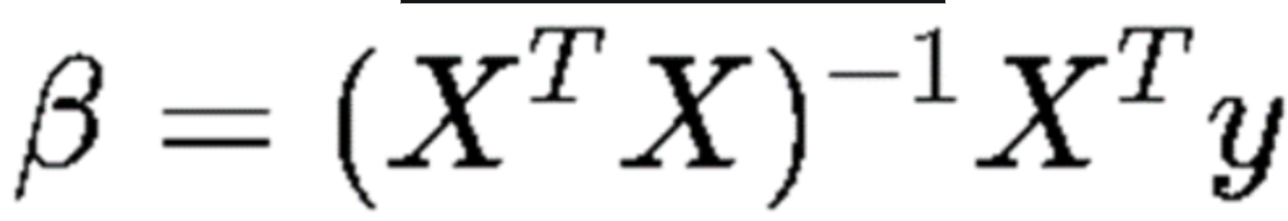
w[0,0] = β₁（斜率），

w[1,0] = β₀（截距）

In [22]:
import numpy as np

year=[1950, 1951, 1952, 1953, 1954, 1955, 1956, 1957, 1958, 1959, 1960,
       1961, 1962, 1963, 1964, 1965, 1966, 1967, 1968, 1969, 1970, 1971,
       1972, 1973, 1974, 1975, 1976, 1977, 1978, 1979, 1980, 1981, 1982,
       1983, 1984, 1985, 1986, 1987, 1988, 1989, 1990, 1991, 1992, 1993,
       1994, 1995, 1996, 1997, 1998, 1999, 2000, 2001, 2002, 2003, 2004,
       2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015,
       2016, 2017, 2018, 2019, 2020]
pop=[2.53, 2.57, 2.62, 2.67, 2.71, 2.76, 2.81, 2.86, 2.92, 2.97, 3.03,
       3.08, 3.14, 3.2 , 3.26, 3.33, 3.4 , 3.47, 3.54, 3.62, 3.69, 3.77,
       3.84, 3.92, 4.  , 4.07, 4.15, 4.22, 4.3 , 4.37, 4.45, 4.53, 4.61,
       4.69, 4.78, 4.86, 4.95, 5.05, 5.14, 5.23, 5.32, 5.41, 5.49, 5.58,
       5.66, 5.74, 5.82, 5.9 , 5.98, 6.05, 6.13, 6.2 , 6.28, 6.36, 6.44,
       6.51, 6.59, 6.67, 6.75, 6.83, 6.92, 7.  , 7.08, 7.16, 7.24, 7.32,
       7.4 , 7.48, 7.56, 7.64, 7.72]

In [38]:
X = np.array(year).reshape(-1,1)
y = np.array(pop).reshape(-1,1)
X.shape,y.shape

((71, 1), (71, 1))

In [39]:
one = np.ones((X.shape[0],1))
X = np.concatenate((X,one),axis=1)
X[:5]

array([[1.950e+03, 1.000e+00],
       [1.951e+03, 1.000e+00],
       [1.952e+03, 1.000e+00],
       [1.953e+03, 1.000e+00],
       [1.954e+03, 1.000e+00]])

In [40]:
w = np.linalg.inv(X.T@X)@X.T@y
w[0,0],w[1,0]


(np.float64(0.07721026156934999), np.float64(-148.31391851093488))

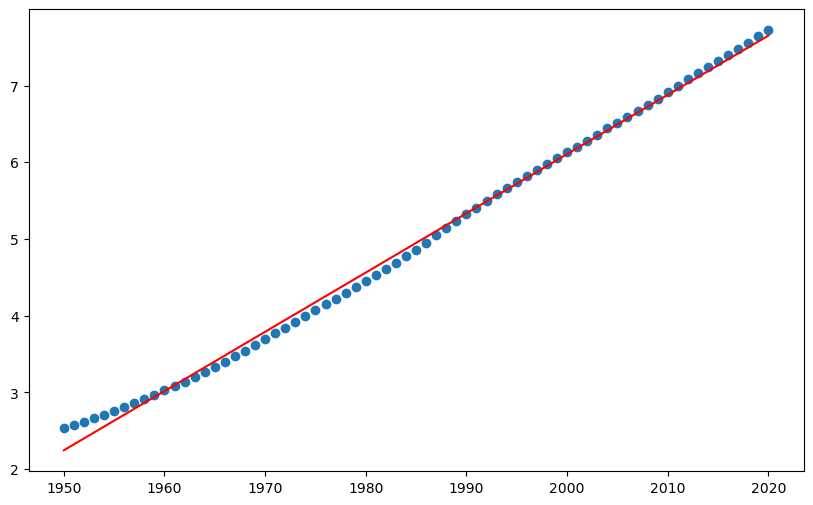

In [42]:
plt.figure(figsize=(10,6))
plt.scatter(X[:,0],y[:,0])
plt.plot(X[:,0],X[:,0]*w[0,0] +w[1,0],"r")

# 使用 SciKit-Learn 進行線性回歸

In [43]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [44]:
df = pd.read_csv("./Advertising.csv")
df.head()

,TV,radio,newspaper,sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9


### 擴展問題

之前，我們探討了**總廣告支出與銷售之間是否存在關聯？**以及預測某一總支出值的總銷售量。現在我們想進一步探討**每個廣告渠道（電視、廣播、報紙）與銷售之間的關係是什麼？**

Text(0.5, 1.0, 'Newspaper')

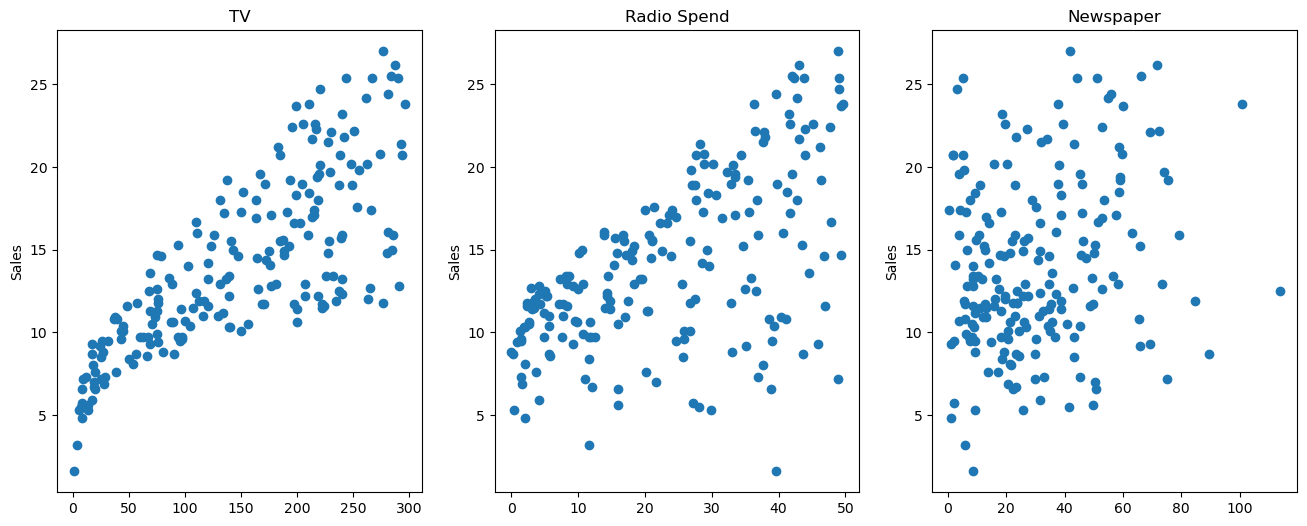

In [51]:
fig,axes = plt.subplots(nrows=1,ncols=3,figsize=(16,6))
axes[0].plot(df["TV"],df["sales"],"o")
axes[0].set_ylabel("Sales")
axes[0].set_title("TV")

axes[1].plot(df["radio"],df["sales"],"o")
axes[1].set_ylabel("Sales")
axes[1].set_title("Radio Spend")


axes[2].plot(df["newspaper"],df["sales"],"o")
axes[2].set_ylabel("Sales")
axes[2].set_title("Newspaper")

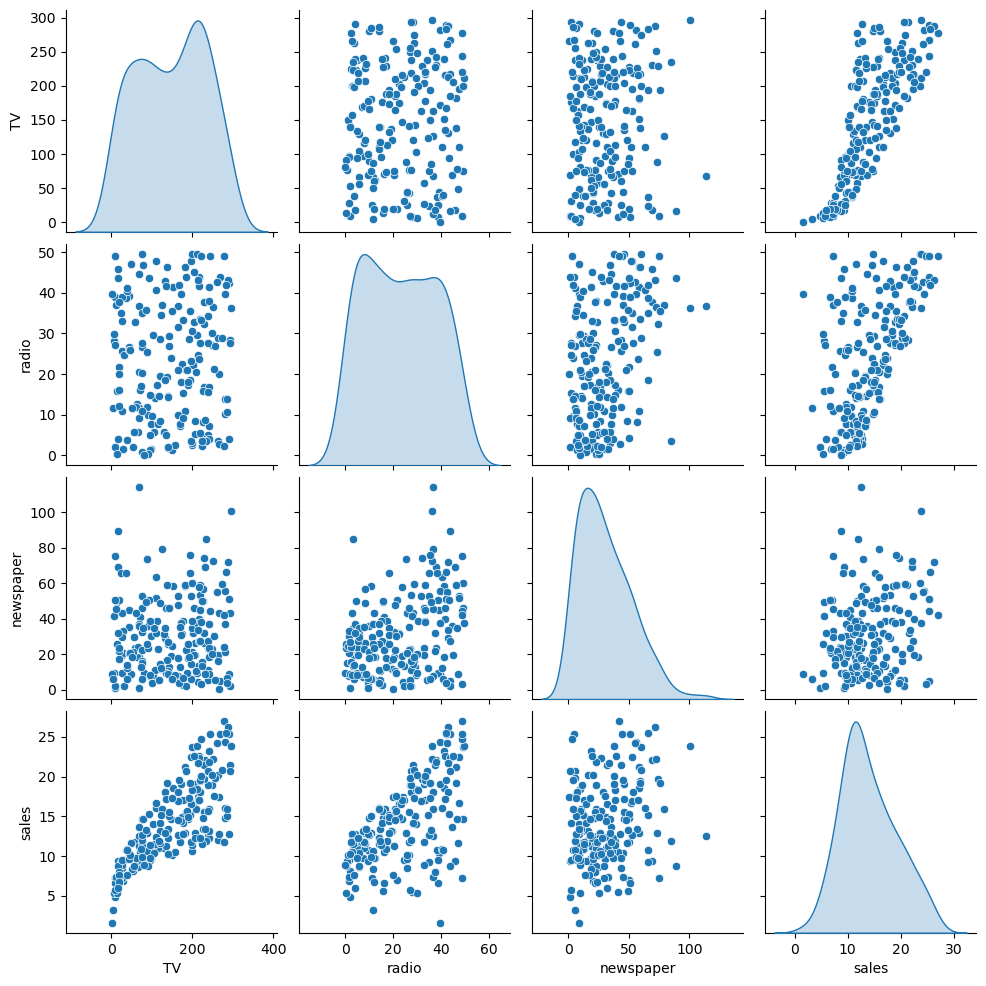

In [52]:
sns.pairplot(df,diag_kind="kde")

In [53]:
X = df.drop("sales",axis=1)
y = df["sales"]
X.shape,y.shape

((200, 3), (200,))

In [54]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.3,random_state=101)
scaler.fit(X_train)
X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)
X_train.shape,X_test.shape,y_train.shape,y_test.shape

((140, 3), (60, 3), (140,), (60,))

In [55]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [56]:
test_pred = model.predict(X_test)

In [ ]:
from sklearn.metrics import mean_squared_error,mean_absolute_error
mae = mean_absolute_error(y_test,test_pred) #不會放大誤差
mse = mean_squared_error(y_test,test_pred) #放大誤差
print(f"MAE:{mae}\nMSE:{mse}")

MAE:1.2137457736144808
MSE:2.2987166978863782


In [58]:
import joblib
joblib.dump((model,scaler),"sales_model_scaler.pkl")

['sales_model_scaler.pkl']